In [1]:
import numpy as np
import pandas as pd
import category_encoders as ce
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, make_scorer,classification_report, roc_auc_score
from ucimlrepo import fetch_ucirepo

Cargamos el conjunto de datos


In [2]:
# fetch dataset 
bank_marketing = fetch_ucirepo(id=222) 
  
# data (as pandas dataframes) 
X = bank_marketing.data.features 
y = bank_marketing.data.targets 
  
# metadata 
#print(bank_marketing.metadata) 
  
# variable information 
#print(bank_marketing.variables) 

Primero, cargamos los datos. Tenemos más de 500 pacientes y 30 características (radio, textura, perímetro). Siempre utilicen X.info() y X.head() al iniciar un proyecto para entender con qué estamos trabajando

In [3]:
# Binarizar y convertir 'y' en una Serie 1D
y = (y['y'] == 'yes').astype(int)

# Verificar los resultados
print(y.value_counts())

y
0    39922
1     5289
Name: count, dtype: int64


Empezamos a tratar los valores nulos a ver que sale

In [4]:
# Identificamos las columnas de texto (object) en X
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# Reemplazamos los NaN por una categoría explícita en las de texto
X[cat_cols] = X[cat_cols].fillna('Unknown')

# Por seguridad, si hubiera algún NaN en las numéricas, usamos la mediana
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21388\263408085.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns.tolist()


### 2. Partición de Datos (Estrategia Train / Dev / Test) Primero separamos el Train (80%) del resto (20%), Luego dividimos el 'resto' en Dev (10%) y Test (10%)

In [5]:

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Luego dividimos el 'resto' en Dev (10%) y Test (10%)
X_dev, X_test, y_dev, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Datos de Entrenamiento (Train): {X_train.shape}")
print(f"Datos de Desarrollo (Dev): {X_dev.shape}")
print(f"Datos de Prueba (Test): {X_test.shape}")

# Inicializamos el One-Hot Encoder para tus columnas de texto
encoder = ce.OneHotEncoder(cols=cat_cols, use_cat_names=True)

# Ajustamos con el set de entrenamiento y transformamos ambos
X_train_encoded = encoder.fit_transform(X_train)
X_test_encoded = encoder.transform(X_test)
X_dev_encoded = encoder.transform(X_dev)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_dev_scaled = scaler.transform(X_dev_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

Datos de Entrenamiento (Train): (36168, 16)
Datos de Desarrollo (Dev): (4521, 16)
Datos de Prueba (Test): (4522, 16)


# Clase 09/09 empezamo a aplicar una Red Neuronal


In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau 
from tensorflow.keras.optimizers import Adam

#### Prueba Lu: Como vimos que reduciendo la tasa de aprendizaje de adam converge mejor, podemos usar ReduceROnPlateau para que cuando la val_loss se estanque, la reduzca automaticamente un poco mas para mejor convergrncia"""

#### Tenemos 51 características por culpa de las variables categóricas, por lo tanto probé empezar con 64 neuronas y lo reduje a 32 en la segunda capa.. como muchas categorías son departamentos de trabajo, pensé en reducirle las neuronas por intuición a que muchas categorías son "fáciles".. esta bién? no sé. mejoró? sí. tambien agregue un optimizador adam manual con un 0 mas (0.001 -> 0.0001) lo que esto hizo fue en los gráficos de perdida y precisión suavizarlos. tambien cambie la metrica como saben el accuracy no nos importa mucho, probé solo con recall... la activacion no la cambié, y el kernel tampoco.

#### Prueba Lu: probando vi que con arquitecturas crecientes tenemos peores resultados que con decrecientes. 
#### Elimine la 4ta capa oculta, y cambie la cantidad de neuronas por capa. El recall mejoró: se redujeron un poco los FN. Al sacarle una capa es una red mas simplona, entrena un poco más rápido y hay menor riesgo de overfitting. Es sólo para ir probando :)

### Cami: Modifique los pesos, el recall baja de 0.89 a 0.87 :(

In [7]:
# Definir el modelo de red neuronal
model = Sequential([
    # Capa de entrada y primera capa oculta con activación ReLU y regularización L2
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],), kernel_regularizer=l2(0.001)),
    Dropout(0.3), # Capa Dropout para mitigar el sobreajuste

    # Segunda capa oculta con activación ReLU y regularización L2
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3), # Capa Dropout

    # Tercera capa oculta con activación ReLU y regularización L2
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3), # Capa Dropout

    # Capa de salida con activación sigmoide para clasificación binaria
    Dense(1, activation='sigmoid')
])

# Compilar el modelo
# Usamos 'Adam' como optimizador, 'binary_crossentropy' como función de pérdida para clasificación binaria,
# y 'recall' como métrica principal.
#model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# Instanciar el optimizador
opt = Adam(learning_rate=0.0001)

model.compile(
    optimizer=opt,
    loss='binary_crossentropy',
    metrics=['recall']
)
# Mostrar un resumen del modelo
print("\nResumen del modelo de red neuronal:")
model.summary()


Resumen del modelo de red neuronal:


c:\Users\ASUS\OneDrive\Documentos\TP Final IA\ClasificacionBanco_IA\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

#### ojo aca, agregué el peso manual haciendo regla de 3 simple con la cantidad de datos redondeando a 45 mil, ¿esta bien? no se. ¿mejoro? mucho :D.

In [8]:
# Definir la llamada de Early Stopping
# Monitorea la 'val_loss' (pérdida en el conjunto de validación)
# 'patience=10' significa que esperará 10 épocas sin mejora antes de detenerse
# 'restore_best_weights=True' restaurará los pesos del modelo de la mejor época
from sklearn.utils import compute_class_weight


early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

"""Como vimos que reduciendo la tasa de aprendizaje de adam converge mejor, podemos usar ReduceROnPlateau para
que cuando la val_loss se estanque, reduzca la tasa de aprendizaje automaticamente reduciendola un poco mas para
mejor convergrncia"""

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)


# Calcular los pesos de clase para compensar el desbalance
# 45000 / (2 * 40000) = 0.56 para la clase 0
# 45000 / (2 * 5000)  = 4.50 para la clase 1
#class_weights = {0: 0.56, 1: 4.5} -- pesos viejos

#Cami -- aca agrego los pesos 
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight = dict(zip(classes, weights))

# Entrenar el modelo
print("\nEntrenando el modelo...")
history = model.fit(
    X_train_scaled, y_train,
    epochs=100, # Número máximo de épocas
    batch_size=64, # Tamaño del lote para el entrenamiento
    validation_data=(X_dev_scaled, y_dev), # Datos de validación
    class_weight=class_weight, #aca aplicamos los pesos de clase para balancear el desbalance
    callbacks=[early_stopping, reduce_lr], # Aplicar Early Stopping #Agregue acá reduce_lr para el ajuste de tasa de adam automatico
    verbose=1 # Mostrar progreso del entrenamiento
)

print("\nEntrenamiento completado.")


Entrenando el modelo...
Epoch 1/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.8579 - recall: 0.6282 - val_loss: 0.8295 - val_recall: 0.8752 - learning_rate: 1.0000e-04
Epoch 2/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7424 - recall: 0.7469 - val_loss: 0.6982 - val_recall: 0.8620 - learning_rate: 1.0000e-04
Epoch 3/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6738 - recall: 0.7809 - val_loss: 0.6351 - val_recall: 0.8696 - learning_rate: 1.0000e-04
Epoch 4/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6299 - recall: 0.8043 - val_loss: 0.5991 - val_recall: 0.8771 - learning_rate: 1.0000e-04
Epoch 5/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6021 - recall: 0.8246 - val_loss: 0.5590 - val_recall: 0.8696 - learning_rate: 1.0000e-04
Epoch 6/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5881 - recall: 0.8379 - val_loss: 0.5710 - val_recall: 0.8960 - learning_rate: 1.0000e-04
Epoch 7/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

#### Las evaluaciones del modelo deje las mismas que el profe.. Lo unico que te hace cambiar es si cambiaron la metrica a recall en la curva de precision tienen que poner recall tambien.

In [9]:
# Evaluar el modelo en el conjunto de prueba
loss, recall = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\Recall del modelo en el conjunto de prueba: {recall:.4f}")
print(f"Pérdida del modelo en el conjunto de prueba: {loss:.4f}")


# Realizar predicciones en el conjunto de prueba
y_pred_proba = model.predict(X_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int) # Convertir probabilidades a clases binarias (0 o 1)

# Mostrar el reporte de clasificación
print("\nReporte de clasificación en el conjunto de prueba:")
print(classification_report(y_test, y_pred))

<>:3: SyntaxWarning: invalid escape sequence '\R'
<>:3: SyntaxWarning: invalid escape sequence '\R'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_21388\379609705.py:3: SyntaxWarning: invalid escape sequence '\R'
  print(f"\Recall del modelo en el conjunto de prueba: {recall:.4f}")


\Recall del modelo en el conjunto de prueba: 0.8733
Pérdida del modelo en el conjunto de prueba: 0.3805
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Reporte de clasificación en el conjunto de prueba:
              precision    recall  f1-score   support

           0       0.98      0.83      0.90      3993
           1       0.41      0.87      0.56       529

    accuracy                           0.84      4522
   macro avg       0.69      0.85      0.73      4522
weighted avg       0.91      0.84      0.86      4522




Matriz de Confusión en el conjunto de prueba:


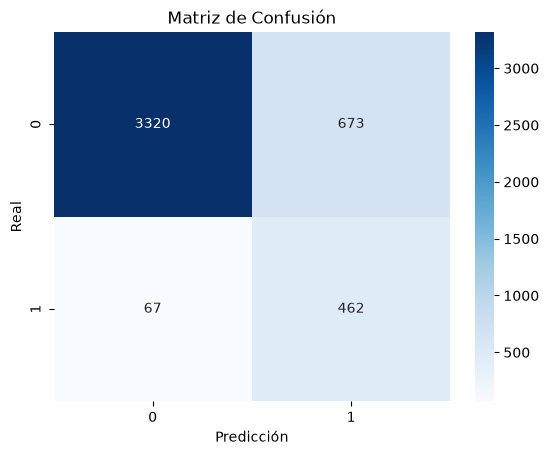

In [10]:
# Mostrar la matriz de confusión
print("\nMatriz de Confusión en el conjunto de prueba:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

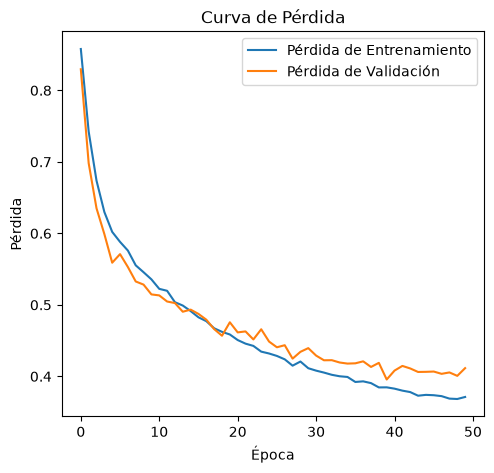

In [11]:
# Visualizar la historia del entrenamiento para detectar sobreajuste
# Curvas de pérdida
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Pérdida de Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de Validación')
plt.title('Curva de Pérdida')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

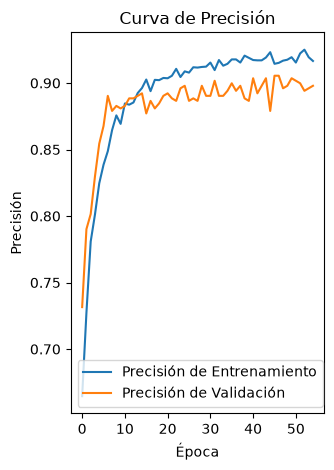


Análisis de las curvas:
 - Si la 'Pérdida de Entrenamiento' disminuye mientras la 'Pérdida de Validación' comienza a aumentar, es una señal clara de sobreajuste.
 - La 'Precisión de Validación' que se estanca o disminuye mientras la 'Precisión de Entrenamiento' sigue mejorando también indica sobreajuste.
 - Gracias a Early Stopping, el entrenamiento se detuvo antes de que el sobreajuste fuera severo, y los mejores pesos se restauraron, lo que se refleja en un buen rendimiento en la validación.


In [12]:
# Curvas de precisión
plt.subplot(1, 2, 2)
plt.plot(history.history['recall'], label='Precisión de Entrenamiento')
plt.plot(history.history['val_recall'], label='Precisión de Validación')
plt.title('Curva de Precisión')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()

plt.tight_layout()
plt.show()

print("\nAnálisis de las curvas:")
print(" - Si la 'Pérdida de Entrenamiento' disminuye mientras la 'Pérdida de Validación' comienza a aumentar, es una señal clara de sobreajuste.")
print(" - La 'Precisión de Validación' que se estanca o disminuye mientras la 'Precisión de Entrenamiento' sigue mejorando también indica sobreajuste.")
print(" - Gracias a Early Stopping, el entrenamiento se detuvo antes de que el sobreajuste fuera severo, y los mejores pesos se restauraron, lo que se refleja en un buen rendimiento en la validación.")